In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
machines = pd.read_csv("../data/PdM_machines.csv")

In [3]:
machines.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


In [44]:
machines["model"].value_counts()

model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

In [12]:
machines.shape

(100, 3)

In [5]:
machines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   machineID  100 non-null    int64 
 1   model      100 non-null    object
 2   age        100 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [6]:
machines.isnull().sum()

machineID    0
model        0
age          0
dtype: int64

In [7]:
machines.duplicated().sum()

np.int64(0)

In [8]:
telemetry = pd.read_csv("../data/PdM_telemetry.csv")

In [10]:
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [11]:
telemetry.shape

(876100, 6)

In [13]:
telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


In [14]:
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])

In [18]:
telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[ns]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 40.1 MB


In [19]:
telemetry.isnull().sum()

datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

In [20]:
telemetry.duplicated().sum()

np.int64(0)

In [21]:
telemetry.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


In [22]:
telemetry["machineID"].nunique()

100

In [23]:
telemetry["machineID"].value_counts().sort_index()

machineID
1      8761
2      8761
3      8761
4      8761
5      8761
       ... 
96     8761
97     8761
98     8761
99     8761
100    8761
Name: count, Length: 100, dtype: int64

In [26]:
machine_1 = telemetry[telemetry["machineID"] == 1]
machine_1.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


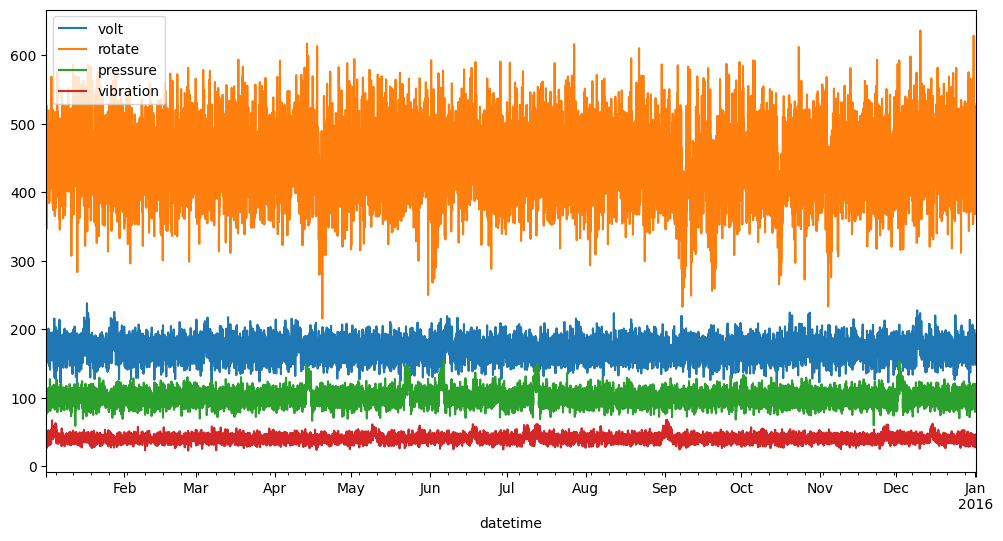

In [27]:
machine_1.plot(
    x="datetime",
    y=["volt", "rotate", "pressure", "vibration"],
    figsize=(12, 6)
)
plt.show()

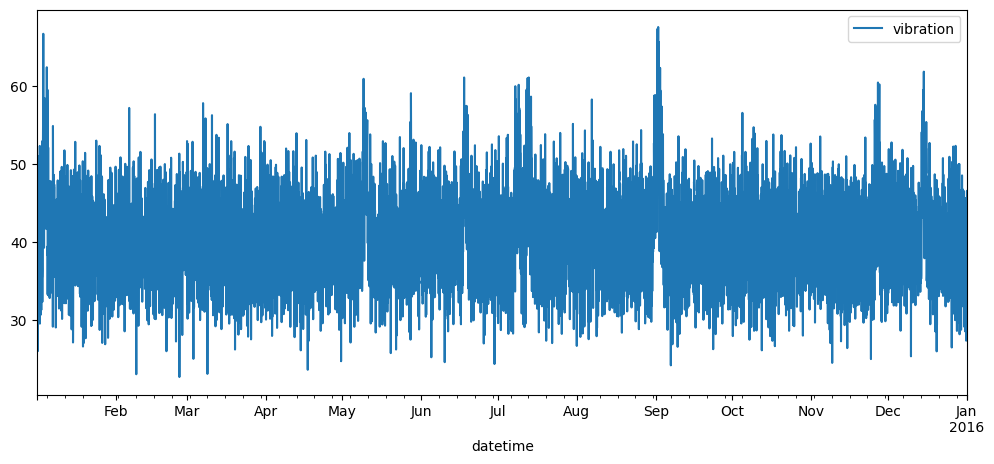

In [28]:
machine_1.plot(
    x="datetime",
    y="vibration",
    figsize=(12, 5)
)
plt.show()

In [29]:
machine_1["vibration"].agg(["mean", "max"])

mean    40.586309
max     67.633435
Name: vibration, dtype: float64

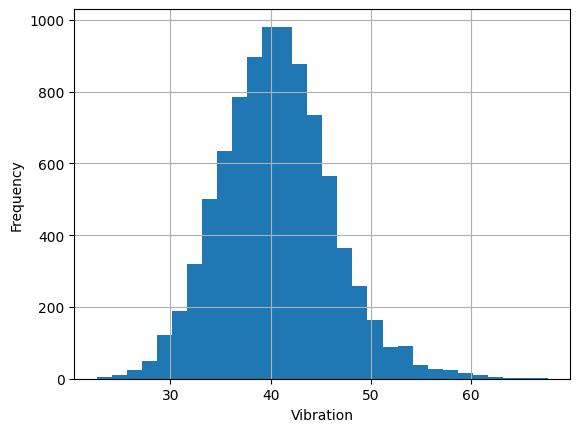

In [30]:
machine_1["vibration"].hist(bins=30)
plt.xlabel("Vibration")
plt.ylabel("Frequency")
plt.show()

In [31]:
machine_1["vibration"].describe()

count    8761.000000
mean       40.586309
std         5.542143
min        22.666865
25%        36.847203
50%        40.417442
75%        44.004311
max        67.633435
Name: vibration, dtype: float64

In [32]:
telemetry.columns

Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration'], dtype='object')

In [33]:
sensor_columns = ["volt", "rotate", "pressure", "vibration"]
telemetry[sensor_columns].corr()

,volt,rotate,pressure,vibration
volt,1.000000,-0.001511,0.001652,0.002390
rotate,-0.001511,1.000000,-0.000688,-0.003056
pressure,0.001652,-0.000688,1.000000,0.001395
vibration,0.002390,-0.003056,0.001395,1.000000


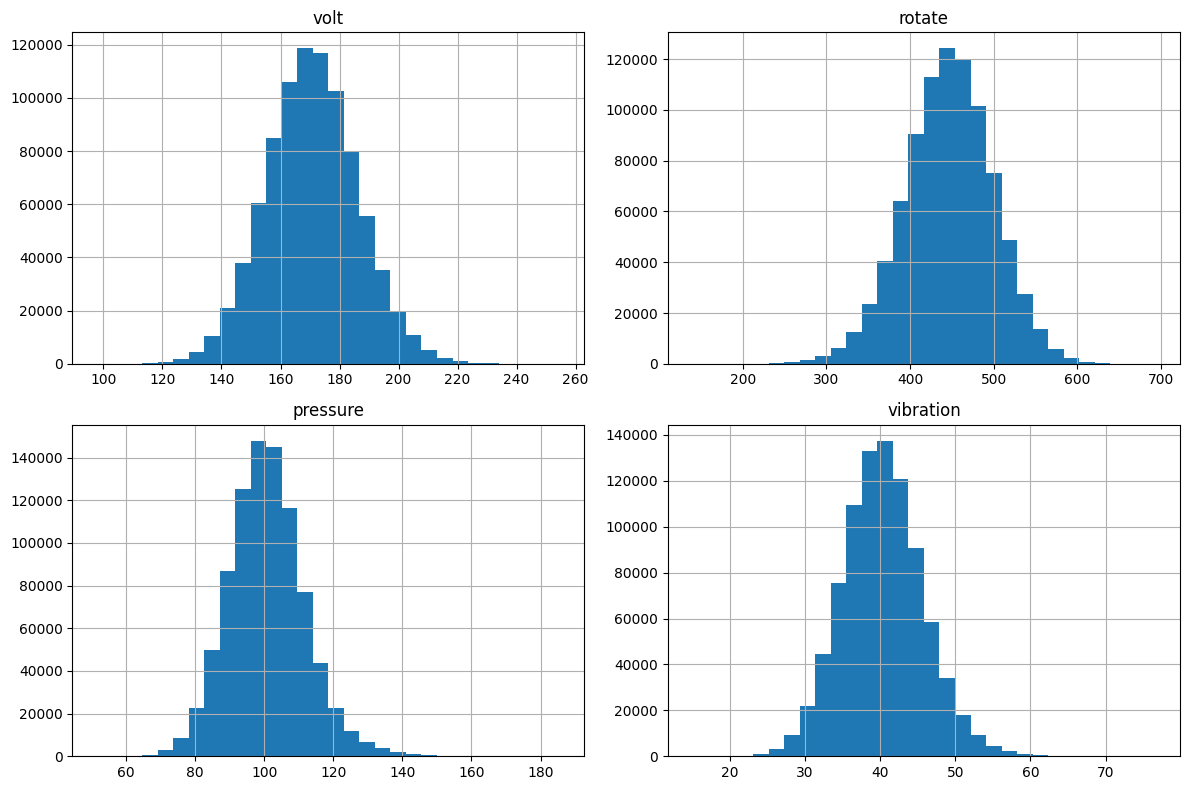

In [34]:
telemetry[sensor_columns].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [35]:
failures = pd.read_csv("../data/PdM_failures.csv")

print("Shape:", failures.shape)

print("\nColumns:")
print(failures.columns)

print("\nInfo:")
failures.info()

print("\nFirst 5 rows:")
display(failures.head())

print("\nNull values:")
print(failures.isnull().sum())

print("\nDuplicate rows:")
print(failures.duplicated().sum())

print("\nFailure types:")
print(failures["failure"].value_counts())

print("\nMachines with failures:")
print(failures["machineID"].nunique())

Shape: (761, 3)

Columns:
Index(['datetime', 'machineID', 'failure'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   761 non-null    object
 1   machineID  761 non-null    int64 
 2   failure    761 non-null    object
dtypes: int64(1), object(2)
memory usage: 18.0+ KB

First 5 rows:


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4



Null values:
datetime     0
machineID    0
failure      0
dtype: int64

Duplicate rows:
0

Failure types:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Machines with failures:
98


In [36]:
failures["datetime"] = pd.to_datetime(failures["datetime"])

failures = failures.sort_values(
    by=["machineID", "datetime"]
).reset_index(drop=True)

print(failures["datetime"].dtype)

display(failures.head(10))

datetime64[ns]


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4
5,2015-10-17 06:00:00,1,comp2
6,2015-12-16 06:00:00,1,comp4
7,2015-03-19 06:00:00,2,comp1
8,2015-03-19 06:00:00,2,comp2
9,2015-04-18 06:00:00,2,comp2


In [37]:
errors = pd.read_csv("../data/PdM_errors.csv")

print("Shape:", errors.shape)

print("\nColumns:")
print(errors.columns)

print("\nFirst 5 rows:")
display(errors.head())

print("\nNull values:")
print(errors.isnull().sum())

print("\nDuplicate rows:")
print(errors.duplicated().sum())

print("\nUnique machines with errors:")
print(errors["machineID"].nunique())

print("\nError types:")
print(errors["errorID"].value_counts())

print("\nDatetime datatype:")
print(errors["datetime"].dtype)

Shape: (3919, 3)

Columns:
Index(['datetime', 'machineID', 'errorID'], dtype='object')

First 5 rows:


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4



Null values:
datetime     0
machineID    0
errorID      0
dtype: int64

Duplicate rows:
0

Unique machines with errors:
100

Error types:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

Datetime datatype:
object


In [38]:
errors["datetime"] = pd.to_datetime(errors["datetime"])

errors = errors.sort_values(
    by=["machineID", "datetime"]
).reset_index(drop=True)

print(errors["datetime"].dtype)

display(errors.head(10))

datetime64[ns]


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4
5,2015-01-25 15:00:00,1,error4
6,2015-01-27 04:00:00,1,error1
7,2015-03-03 22:00:00,1,error2
8,2015-03-05 06:00:00,1,error1
9,2015-03-20 18:00:00,1,error1


In [39]:
maint = pd.read_csv("../data/PdM_maint.csv")

print("Shape:", maint.shape)

print("\nColumns:")
print(maint.columns)

print("\nFirst 5 rows:")
display(maint.head())

print("\nNull values:")
print(maint.isnull().sum())

print("\nDuplicate rows:")
print(maint.duplicated().sum())

print("\nUnique machines:")
print(maint["machineID"].nunique())

print("\nMaintenance types:")
print(maint["comp"].value_counts())

print("\nDatetime datatype:")
print(maint["datetime"].dtype)

Shape: (3286, 3)

Columns:
Index(['datetime', 'machineID', 'comp'], dtype='object')

First 5 rows:


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4



Null values:
datetime     0
machineID    0
comp         0
dtype: int64

Duplicate rows:
0

Unique machines:
100

Maintenance types:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64

Datetime datatype:
object


In [40]:
maint["datetime"] = pd.to_datetime(maint["datetime"])

maint = maint.sort_values(
    by=["machineID", "datetime"]
).reset_index(drop=True)

print(maint["datetime"].dtype)

display(maint.head(10))

datetime64[ns]


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4
5,2015-01-05 06:00:00,1,comp1
6,2015-01-20 06:00:00,1,comp3
7,2015-01-20 06:00:00,1,comp1
8,2015-02-04 06:00:00,1,comp4
9,2015-02-04 06:00:00,1,comp3


In [41]:
print(machines.columns)

display(machines.head())

print("\nMachine models:")
print(machines["model"].value_counts())

print("\nMachine age statistics:")
print(machines["age"].describe())

Index(['machineID', 'model', 'age'], dtype='object')


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2



Machine models:
model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

Machine age statistics:
count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64


In [45]:
telemetry = telemetry.merge(
    machines[["machineID", "age"]],
    on="machineID",
    how="left",
    validate="many_to_one"
)

telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18


In [49]:
# Work on a copy; the existing age merge is reused.
df = telemetry.copy()
if "age" not in df.columns:
    df = df.merge(
        machines[["machineID", "age"]],
        on="machineID",
        how="left",
        validate="many_to_one"
    )

# Process whole arrays per machine, rather than looping over telemetry rows.
error_counts = np.zeros(len(df), dtype=int)
maintenance_hours = np.full(len(df), np.nan)
failure_labels = np.zeros(len(df), dtype=int)
window = np.timedelta64(24, "h")

for machine_id, positions in df.groupby("machineID").indices.items():
    times = df.iloc[positions]["datetime"].to_numpy(dtype="datetime64[ns]")
    error_times = errors.loc[
        errors["machineID"] == machine_id, "datetime"
    ].to_numpy(dtype="datetime64[ns]")
    maintenance_times = maint.loc[
        maint["machineID"] == machine_id, "datetime"
    ].to_numpy(dtype="datetime64[ns]")
    failure_times = failures.loc[
        failures["machineID"] == machine_id, "datetime"
    ].to_numpy(dtype="datetime64[ns]")

    # Event tables were already sorted in the existing cells.
    for event_times in (error_times, maintenance_times, failure_times):
        assert not np.isnat(event_times).any()
        assert (event_times[:-1] <= event_times[1:]).all()
    assert not np.isnat(times).any()

    # Count every error in (time - 24 hours, time], including simultaneous errors.
    start = np.searchsorted(error_times, times - window, side="right")
    end = np.searchsorted(error_times, times, side="right")
    error_counts[positions] = end - start
    has_errors = end > start
    assert (error_times[start[has_errors]] > times[has_errors] - window).all()
    assert (error_times[end[has_errors] - 1] <= times[has_errors]).all()

    # The last maintenance at or before the reading; no history stays NaN.
    previous = np.searchsorted(maintenance_times, times, side="right") - 1
    has_maintenance = previous >= 0
    last_maintenance = maintenance_times[previous[has_maintenance]]
    assert (last_maintenance <= times[has_maintenance]).all()
    maintenance_hours[positions[has_maintenance]] = (
        (times[has_maintenance] - last_maintenance) / np.timedelta64(1, "h")
    )

    # Look forward only for the target: time < failure <= time + 24 hours.
    following = np.searchsorted(failure_times, times, side="right")
    has_future_failure = following < len(failure_times)
    next_failure = failure_times[following[has_future_failure]]
    assert (next_failure > times[has_future_failure]).all()
    failure_labels[positions[has_future_failure]] = (
        next_failure <= times[has_future_failure] + window
    ).astype(int)

df["errors_last_24h"] = error_counts
df["hours_since_last_maintenance"] = maintenance_hours
df["failure_next_24h"] = failure_labels

In [48]:
# Confirm that integration preserved the readings and their order.
assert len(df) == len(telemetry), "Telemetry row count changed"
if not telemetry.duplicated(["machineID", "datetime"]).any():
    assert not df.duplicated(["machineID", "datetime"]).any()

original_columns = telemetry.columns.tolist()
pd.testing.assert_frame_equal(
    df[original_columns].reset_index(drop=True),
    telemetry.reset_index(drop=True)
)
assert df["failure_next_24h"].isin([0, 1]).all()
assert (df["errors_last_24h"] >= 0).all()
assert (df["hours_since_last_maintenance"].dropna() >= 0).all()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
print("\nNull values:")
print(df.isnull().sum())
print("\nFailure target counts:")
print(df["failure_next_24h"].value_counts().sort_index())
print("\nHistorical feature statistics:")
display(df[["errors_last_24h", "hours_since_last_maintenance"]].describe())
print("Validation passed: row count, unique keys, original values, and time boundaries.")

Shape: (876100, 10)
Columns: ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'age', 'errors_last_24h', 'hours_since_last_maintenance', 'failure_next_24h']


,datetime,machineID,volt,rotate,pressure,vibration,age,errors_last_24h,hours_since_last_maintenance,failure_next_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,0,456.0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,0,457.0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,0,458.0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,0,459.0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,0,460.0,0



Null values:
datetime                        0
machineID                       0
volt                            0
rotate                          0
pressure                        0
vibration                       0
age                             0
errors_last_24h                 0
hours_since_last_maintenance    0
failure_next_24h                0
dtype: int64

Failure target counts:
failure_next_24h
0    858916
1     17184
Name: count, dtype: int64

Historical feature statistics:


,errors_last_24h,hours_since_last_maintenance
count,876100.000000,876100.000000
mean,0.107253,263.621687
std,0.353272,322.139335
min,0.000000,0.000000
25%,0.000000,102.000000
50%,0.000000,205.000000
75%,0.000000,309.000000
max,4.000000,4079.000000


Validation passed: row count, unique keys, original values, and time boundaries.
